# DTGS172. Simulating Bacteria

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/1-getting-started/DTGS172_bacteria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

In addition to simple geometric scatterers, DeepTrack also makes it possible to describe biological structures with more complex shapes. The examples below show how common bacterial morphologies can be represented as scatterers. These implementations are not intended as exact models of bacterial structure, but rather as demonstrations of how such scatterers can be created and adapted. You can use them directly, or take them as inspiration to design custom scatterers that fit your own application.

The examples are implemented in NumPy, though the same approach can be applied in PyTorch.

If you would like to understand in more detail how scatterers are constructed in DeepTrack, you may first want to look at the introductory tutorial on custom scatterers [DTGS171A_custom_scatterers.ipynb](./DTGS171A_custom_scatterers.ipynb), which you should ideally peruse before this tutorial.

In [ ]:
import deeptrack as dt
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from deeptrack import units as u
from deeptrack.backend.units import ConversionTable
from deeptrack.optical.scatterers import VolumeScatterer

## 1. Simulating Rod-Shaped Bacilli

Rod-shaped bacteria (bacilli) can be represented by combining a cylinder with hemispherical caps. The example `Bacillus` class below also includes the option to add bending along the length of the rod.

In [4]:
class Bacillus(VolumeScatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
        self,
        radius=0.4e-6,
        length=2e-6,
        rotation=(0, 0, 0),
        bend=0,
        refractive_index=1.38,
        **kwargs,
    ):
        super().__init__(
            radius=radius,
            length=length,
            rotation=rotation,
            bend=bend,
            refractive_index=refractive_index,
            **kwargs,
        )

    def _process_properties(self, properties):
        properties = super()._process_properties(properties)

        # Ensure radius is scalar
        radius = np.array(properties["radius"])
        if radius.size > 1:
            radius = radius[0]
        properties["radius"] = float(radius)

        # Ensure length is scalar
        properties["length"] = float(properties["length"])

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        length,
        rotation,
        bend,
        voxel_size,
        **kwargs,
    ):

        # Determine grid size
        rad_ceil = np.ceil(radius / np.min(voxel_size[:2]))
        len_ceil = np.ceil(length * 0.5 / voxel_size[2]) + rad_ceil
        ceil = int(max(rad_ceil, len_ceil))

        # Create the grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate the grid
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        # Apply wave-like bending along the length of the bacillus
        lateral_offset_x = bend * np.cos(np.pi * YR / length)
        XR -= lateral_offset_x

        # Cylinder mask
        cyl_mask = ((XR**2 / radius**2 + ZR**2 / radius**2) < 1) & (
            np.abs(YR) < (length / 2)
        )
        # Hemispherical caps
        cap_mask = (
            XR**2 + ZR**2 + (np.abs(YR) - (length / 2)) ** 2
        ) < radius**2

        # Combine cylinder with end-caps to form the full bacillus shape
        mask = cyl_mask | cap_mask

        # Hollow out an inner capsule to leave only the cell envelope (shell)
        inner_radius = radius * 0.6
        inner_length = length * 0.9

        cyl_mask_in = (
            (XR**2 / inner_radius**2 + ZR**2 / inner_radius**2) < 1
        ) & (np.abs(YR) < (inner_length / 2))
        cap_mask_in = (
            XR**2 + ZR**2 + (np.abs(YR) - (inner_length / 2)) ** 2
        ) < inner_radius**2
        mask_in = cyl_mask_in | cap_mask_in

        shell = mask & ~mask_in
        return shell.astype(float)

In [5]:
image_size = 128

bacillus = Bacillus(position=(image_size // 2, image_size // 2))

optics_fluo = dt.Fluorescence(
    resolution=1e-7,
    magnification=1,
    NA=1.0,
    output_region=(0, 0, image_size, image_size),
)

pip = optics_fluo(bacillus)

C:\Users\xgrmir\Desktop\DT_test\DeepTrack2\deeptrack\optical\optics.py:1418: UserWarning: Scatterer defines 'refractive_index', which is ignored in fluorescence microscopy.
  warnings.warn(
C:\Users\xgrmir\Desktop\DT_test\DeepTrack2\deeptrack\optical\optics.py:1429: UserWarning: Fluorescence scatterer has no 'intensity'. Interpreting 'value' as a non-physical brightness factor. Quantitative interpretation is invalid. Define 'intensity' to model physical fluorescence emission.
  warnings.warn(


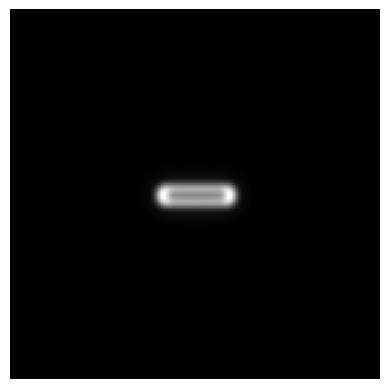

In [6]:
pip.update()
image = pip.resolve()

plt.imshow(image, cmap="gray")
plt.axis('off');

Once defined, bacilli can be placed at specific or random positions, given random orientations, and varied in size. Several instances can be combined into the same simulation, with tools such as `NonOverlapping` to avoid overlaps.

In [8]:
max_bacillus_bend = 2e-7

bacillus = Bacillus(
    position=lambda: np.random.uniform(10, image_size - 10, 2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
    length=lambda: np.random.uniform(1.4e-6, 2.2e-6),
    bend=lambda: (np.random.rand() - 0.5) * 2 * max_bacillus_bend,
)

multiple_bacilli = bacillus ^ (lambda: np.random.randint(5, 10))

non_overlap_bac = dt.NonOverlapping(multiple_bacilli, min_distance=3)

pip = optics_fluo(non_overlap_bac)

C:\Users\xgrmir\Desktop\DT_test\DeepTrack2\deeptrack\optical\optics.py:1418: UserWarning: Scatterer defines 'refractive_index', which is ignored in fluorescence microscopy.
  warnings.warn(
C:\Users\xgrmir\Desktop\DT_test\DeepTrack2\deeptrack\optical\optics.py:1429: UserWarning: Fluorescence scatterer has no 'intensity'. Interpreting 'value' as a non-physical brightness factor. Quantitative interpretation is invalid. Define 'intensity' to model physical fluorescence emission.
  warnings.warn(


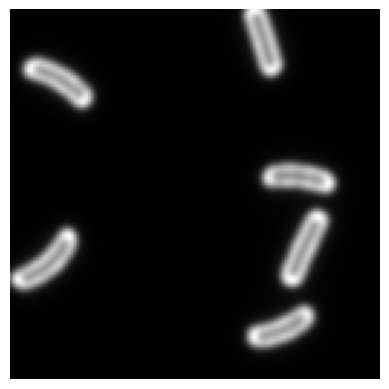

In [9]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap="gray")
plt.axis('off');

## 2. Simulating Chains of Bacilli

In addition to single bacilli, we can also model chains of bacteria, arranging multiple rods end-to-end to represent either dividing cells or naturally chain-forming bacteria such as streptobacilli. The class below allows both the individual rods and the entire chain to bend slightly.

In [10]:
class ChainBacillus(VolumeScatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
        chain_bend=(u.radian, u.radian),  # an ANGLE (per-joint)
    )

    def __init__(
        self,
        radius=0.4e-6,
        length=2e-6,
        n_bacilli=5,
        rotation=(0, 0, 0),
        chain_bend=0,
        bacillus_bend=0,
        overlap_fraction=0.02,
        refractive_index=1.38,
        **kwargs
    ):
        super().__init__(
            radius=radius,
            length=length,  # length of each part of the chain
            n_bacilli=n_bacilli,
            rotation=rotation,
            chain_bend=chain_bend,
            bacillus_bend=bacillus_bend,
            overlap_fraction=overlap_fraction,
            refractive_index=refractive_index,
            **kwargs
        )

    def _process_properties(self, properties):
        properties = super()._process_properties(properties)

        # Ensure radius is scalar
        radius = np.array(properties["radius"])
        if radius.size > 1:
            radius = radius[0]
        properties["radius"] = float(radius)

        # Ensure length is float or iterable of floats
        length = properties["length"]
        if np.ndim(length) == 0:
            properties["length"] = float(length)
        else:
            properties["length"] = np.array(length, dtype=float)

        # Ensure n_bacilli is int
        properties["n_bacilli"] = int(properties.get("n_bacilli"))

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        length,
        n_bacilli,
        rotation,
        chain_bend,
        bacillus_bend,
        overlap_fraction,
        voxel_size,
        **kwargs
    ):
        # Determine grid size
        rad_ceil = np.ceil(radius / np.min(voxel_size[:2]))
        len_ceil = (
            np.ceil(length * 0.5 * n_bacilli / voxel_size[2])
            + rad_ceil * n_bacilli
        )
        ceil = int(max(rad_ceil, len_ceil))

        # Create grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Base 3D rotation of the whole chain
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        # Consecutive segments are spaced slightly CLOSER than exact
        # end-to-end tangency, since two capsules that only just touch meet
        # at a single, measure-zero point that often falls between sampled
        # voxels on a discrete grid, rendering as a visible gap.
        capsule_half_length = length / 2 + radius
        place_half_length = capsule_half_length * (1 - overlap_fraction)

        # True hinge construction: each segment's center sits exactly
        # `place_half_length` from a SHARED pivot point, along its OWN
        # heading -- so consecutive rods pivot around a common joint rather
        # than being offset sideways from each other. Heading itself is a
        # random walk, bounded by +/- chain_bend per joint.
        heading = 0.0
        headings = [heading]
        hinge = np.array([0.0, 0.0])
        direction = np.array([np.sin(heading), np.cos(heading)])
        center = hinge + place_half_length * direction
        centers = [center]
        hinge = (
            center + place_half_length * direction
        )  # this segment's far end

        for i in range(1, n_bacilli):
            heading += chain_bend
            headings.append(heading)
            direction = np.array([np.sin(heading), np.cos(heading)])
            center = hinge + place_half_length * direction
            centers.append(center)
            hinge = center + place_half_length * direction  # next joint

        centers = np.array(centers)
        mean_xy = centers.mean(axis=0)

        shell = np.zeros_like(XR, dtype=bool)
        for (cx, cy), seg_heading in zip(centers, headings):
            dx = XR - (cx - mean_xy[0])
            dy = YR - (cy - mean_xy[1])
            local_x = dx * np.cos(seg_heading) - dy * np.sin(seg_heading)
            local_y = dx * np.sin(seg_heading) + dy * np.cos(seg_heading)
            local_z = ZR

            lateral_offset_x = bacillus_bend * np.cos(np.pi * local_y / length)
            local_x = local_x - lateral_offset_x

            cyl_mask = (
                (local_x**2 / radius**2 + local_z**2 / radius**2) < 1
            ) & (np.abs(local_y) < length / 2)

            cap_mask = (
                local_x**2 + local_z**2 + (np.abs(local_y) - length / 2) ** 2
            ) < radius**2

            mask0 = cyl_mask | cap_mask

            inner_radius = radius * 0.6
            inner_length = length * 0.9

            cyl_mask_in = (
                (local_x**2 / inner_radius**2 + local_z**2 / inner_radius**2)
                < 1
            ) & (np.abs(local_y) < (inner_length / 2))
            cap_mask_in = (
                local_x**2
                + local_z**2
                + (np.abs(local_y) - (inner_length / 2)) ** 2
            ) < inner_radius**2
            mask_in = cyl_mask_in | cap_mask_in

            shell |= mask0 & ~mask_in

        return shell.astype(float)

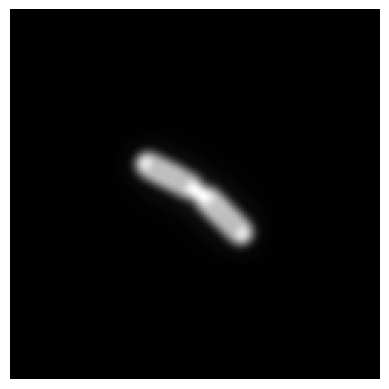

In [12]:
max_chain_bend = np.pi / 10
max_bacillus_bend2 = 1e-7

chain_bacillus = ChainBacillus(
    position=(image_size // 2, image_size // 2),
    length=lambda: np.random.uniform(1.4e-6, 1.8e-6),
    n_bacilli=2,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
    chain_bend=lambda: (np.random.rand() - 0.5) * 2 * (max_chain_bend),
    bacillus_bend=lambda: (np.random.rand() - 0.5) * 2 * max_bacillus_bend2,
    refractive_index=lambda: np.random.uniform(1.38, 1.42),
)

optics = dt.Fluorescence(output_region=(0, 0, image_size, image_size))

pip = optics(chain_bacillus)

pip.update()
image = pip.resolve()
plt.imshow(image, cmap="gray")
plt.axis('off');

The two-segment chain above could represent a pair of dividing cells that have not yet fully separated. Increasing the number of bacilli per chain, and placing several such chains at random positions, instead produces longer, streptobacilli-like chains, as shown below.

In [15]:
image_size_big = 256

max_chain_bend2 = np.pi / 25

chain_bacillus = ChainBacillus(
    position=lambda: np.random.uniform(25, image_size_big - 25, 2),
    n_bacilli=lambda: np.random.randint(4, 10),
    chain_bend=lambda: (np.random.rand() - 0.5) * 2 * (max_chain_bend),
    bacillus_bend=lambda: (np.random.rand() - 0.5) * 2 * max_bacillus_bend2,
    refractive_index=lambda: np.random.uniform(1.38, 1.42),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
    overlap_fraction=0,
)

optics = dt.Fluorescence(output_region=(0, 0, image_size_big, image_size_big))

pip = optics(chain_bacillus ^ 2)

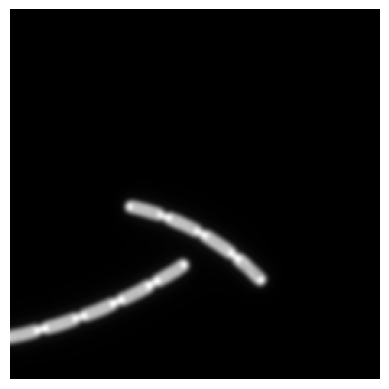

In [16]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap="gray")
plt.axis('off');

## 3. Simulating Chains of Spherical Cells

In addition to rod-shaped chains, we can also model spherical cells arranged in chains, describing each cell as a sphere placed along an axis. The example `SphericalChain` class implements this approach, and also allows the chain to bend smoothly.

In [17]:
class SphericalChain(VolumeScatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
        self,
        radius=0.5e-6,
        n_coccus=5,
        rotation=(0, 0, 0),
        max_chain_bend=0,
        refractive_index=1.38,
        **kwargs
    ):
        super().__init__(
            radius=radius,
            n_coccus=n_coccus,
            rotation=rotation,
            max_chain_bend=max_chain_bend,
            refractive_index=refractive_index,
            **kwargs
        )

    def _process_properties(self, properties):
        properties = super()._process_properties(properties)

        # Ensure radius is scalar
        radius = np.array(properties["radius"])
        if radius.size > 1:
            radius = radius[0]
        properties["radius"] = float(radius)

        # Ensure n_coccus is int
        properties["n_coccus"] = int(properties.get("n_coccus"))

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        n_coccus,
        rotation,
        max_chain_bend,
        voxel_size,
        **kwargs
    ):
        # Determine grid size
        rad_ceil = np.ceil(radius / np.min(voxel_size[:2]))
        len_ceil = rad_ceil * n_coccus
        ceil = len_ceil

        # Create grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate the grid
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        shift = 2 * radius
        total_length = n_coccus * 2 * radius

        # Generate smooth random offsets along the chain
        bend_x_offsets = (np.random.rand(n_coccus) - 0.5) * 2 * max_chain_bend
        bend_z_offsets = (np.random.rand(n_coccus) - 0.5) * 2 * max_chain_bend

        # Smooth offsets for more natural curve
        for i in range(1, n_coccus):
            bend_x_offsets[i] = (
                0.7 * bend_x_offsets[i - 1] + 0.3 * bend_x_offsets[i]
            )
            bend_z_offsets[i] = (
                0.7 * bend_z_offsets[i - 1] + 0.3 * bend_z_offsets[i]
            )

        shell = np.zeros_like(XR, dtype=bool)

        for i in range(n_coccus):
            # Shift along Y and add realistic random bend
            YR_shifted = YR - i * shift + total_length / 2 - shift / 2
            XR_shifted = XR - bend_x_offsets[i]
            ZR_shifted = ZR - bend_z_offsets[i]

            dist_sq = XR_shifted**2 + YR_shifted**2 + ZR_shifted**2
            coccus_mask = dist_sq < radius**2

            # Hollow out an inner sphere to leave only the cell envelope (shell)
            inner_radius = radius * 0.6
            coccus_mask_in = dist_sq < inner_radius**2

            shell |= coccus_mask & ~coccus_mask_in

        return shell.astype(float)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

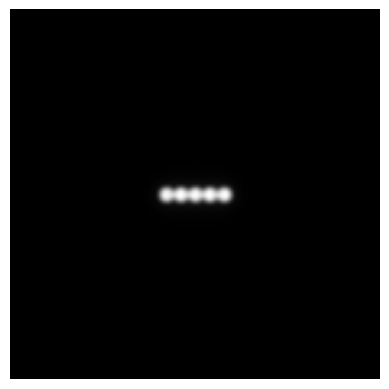

In [18]:
spherical_chain = SphericalChain(
    position=(image_size_big // 2, image_size_big // 2)
)

optics = dt.Fluorescence(output_region=(0, 0, image_size_big, image_size_big))

pip = optics(spherical_chain)

pip.update()
image = pip.resolve()
plt.imshow(image, cmap="gray")
plt.axis("off")

Parameters such as the number of spheres, their radius, and the amount of bending can be adjusted. As with the other examples, several chains can be placed in the same image.

In [19]:
spherical_chain = SphericalChain(
    position=lambda: np.random.uniform(50, image_size_big - 50, 2),
    n_coccus=lambda: np.random.randint(5, 12),
    max_chain_bend=1.5e-6,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

optics = dt.Fluorescence(output_region=(0, 0, image_size_big, image_size_big))

pip = optics(spherical_chain ^ 3)

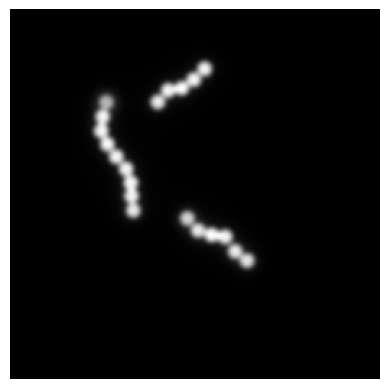

In [21]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap="gray")
plt.axis('off');

## 4. Simulating Different Imaging Modalities

Populations of individual bacilli and short bacterial chains can be combined into a single sample and imaged with different optical systems, such as fluorescence, brightfield, and darkfield microscopy. Sensor noise and blur are added to each modality to make the resulting images resemble real microscopy data more closely.

In [22]:
optics_fluo = dt.Fluorescence(
    resolution=1e-7,
    magnification=1,
    NA=1.0,
    output_region=(0, 0, image_size_big, image_size_big),
)

optics_bf = dt.Brightfield(
    resolution=1e-7,
    magnification=1,
    NA=1.2,
    refractive_index_medium=1.33,
    output_region=(0, 0, image_size_big, image_size_big),
)

optics_df = dt.Darkfield(
    resolution=1e-7,
    magnification=1,
    NA=1.0,
    refractive_index_medium=1.33,
    output_region=(0, 0, image_size_big, image_size_big),
)

In [23]:
max_bacillus_bend = 2e-7
bacillus = Bacillus(
    position=lambda: np.random.uniform(10, image_size_big - 10, 2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
    length=lambda: np.random.uniform(1.4e-6, 2.2e-6),
    bend=lambda: (np.random.rand() - 0.5) * 2 * max_bacillus_bend,
    refractive_index=lambda: np.random.uniform(1.38, 1.42),
)

max_bacillus_bend2 = 1e-7
max_chain_bend = np.pi / 10

chain_bacilli = ChainBacillus(
    position=lambda: np.random.uniform(10, image_size_big - 10, 2),
    length=lambda: np.random.uniform(1.4e-6, 1.8e-6),
    n_bacilli=2,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
    chain_bend=lambda: (np.random.rand() - 0.5) * 2 * (max_chain_bend),
    bacillus_bend=lambda: (np.random.rand() - 0.5) * 2 * max_bacillus_bend2,
    refractive_index=lambda: np.random.uniform(1.38, 1.42),
)

multiple_bacilli = bacillus ^ (lambda: np.random.randint(5, 10))
multiple_chains = chain_bacilli ^ (lambda: np.random.randint(3, 4))

bac = multiple_bacilli & multiple_chains

In [24]:
pip_bf = (
    optics_bf(bac) >> dt.Gaussian(sigma=0.035) >> dt.GaussianBlur(sigma=2.4)
)
pip_df = (
    optics_df(bac) >> dt.Gaussian(sigma=0.00135) >> dt.GaussianBlur(sigma=1.6)
)
pip_fluo = optics_fluo(bac) >> dt.Poisson(snr=10)
pip_modalities = pip_fluo & pip_bf & pip_df

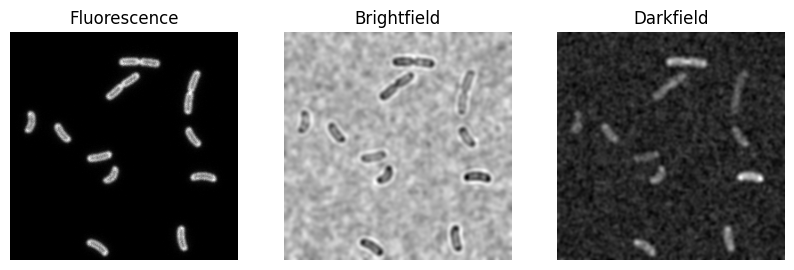

In [28]:
pip_modalities.update()
image_fluo, image_bf, image_df = pip_modalities.resolve()

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

ax[0].imshow(image_fluo, cmap="gray")
ax[0].set_title("Fluorescence")
ax[0].axis("off")
ax[1].imshow(image_bf, cmap="gray")
ax[1].set_title("Brightfield")
ax[1].axis("off")
ax[2].imshow(image_df, cmap="gray")
ax[2].set_title("Darkfield")
ax[2].axis("off");